# Importing libraries and source data

In [552]:
import pandas as pd

import numpy as np

# import class for replacing missing values
from sklearn.impute import SimpleImputer

# import class creating column transformers
from sklearn.compose import ColumnTransformer

# import 'matplotlib' library's 'pyplot' interface for creating charts/plots
import matplotlib.pyplot as plt

# import chart style sheets
from matplotlib import style
# which style sheet to use
style.use('ggplot')

# import 'ipywidgets' library for creating widgets
import ipywidgets as widgets


In [553]:
# base data
inputfolderpath = r'D:\Projects\Video_games_sales'
inputfile = 'vgsales.csv'

In [554]:
# read data from csv
df = pd.read_csv(inputfolderpath + '\\' + inputfile, sep = ',', encoding = 'utf-8', on_bad_lines="skip")
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


# Deleting the unnecessary columns, unpivot the dataframe, replacing values

In [556]:
df = df.drop(['Rank', 'Global_Sales'], axis = 1)
df.head()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00


In [557]:
df_long = df.melt(id_vars= ['Name', 'Platform', 'Year', 'Genre', 'Publisher'], 
                  var_name= ['Territory'], value_name= 'Revenue')
df_long.head()

,Name,Platform,Year,Genre,Publisher,Territory,Revenue
0,Wii Sports,Wii,2006.0,Sports,Nintendo,NA_Sales,41.49
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,NA_Sales,29.08
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,NA_Sales,15.85
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,NA_Sales,15.75
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,NA_Sales,11.27


In [558]:
df = df_long
df.head()

,Name,Platform,Year,Genre,Publisher,Territory,Revenue
0,Wii Sports,Wii,2006.0,Sports,Nintendo,NA_Sales,41.49
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,NA_Sales,29.08
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,NA_Sales,15.85
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,NA_Sales,15.75
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,NA_Sales,11.27


In [559]:
df['Territory'] = df['Territory'].str.replace('NA_Sales', 'North_America').str.replace('EU_Sales', 'EU').str.replace('JP_Sales', 'Japan').str.replace('Other_Sales', 'Other')
df.head()

,Name,Platform,Year,Genre,Publisher,Territory,Revenue
0,Wii Sports,Wii,2006.0,Sports,Nintendo,North_America,41.49
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,North_America,29.08
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,North_America,15.85
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,North_America,15.75
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,North_America,11.27


In [560]:
df.dtypes

Name          object
Platform      object
Year         float64
Genre         object
Publisher     object
Territory     object
Revenue      float64
dtype: object

# Show missing values

In [562]:
# show number of missing values per column
def show_number_of_missing(df):
    # show number of missing values per column
    for column in df.columns:
        missingvalues = df.loc[ df[column].isnull() ].shape[0]
        print(f'{column}: {missingvalues} value(s) missing')

In [563]:
# show number of missing values per column
show_number_of_missing(df)


Name: 0 value(s) missing
Platform: 0 value(s) missing
Year: 1084 value(s) missing
Genre: 0 value(s) missing
Publisher: 232 value(s) missing
Territory: 0 value(s) missing
Revenue: 0 value(s) missing


# Put the numeric and categorical features to list

In [565]:
# add categorical and numeric features to list
def add_categ_numeric_features_to_list(df):
    categorical_features = []
    numeric_features = []

    for column in df.columns:
        # if column is float (f) or integer (i) type
        if df[column].dtype.kind in 'fi':
            numeric_features.append(column)
        else:
            categorical_features.append(column)

    return (categorical_features, numeric_features)

In [566]:
# add categorical and numeric features to list
categorical_features, numeric_features = add_categ_numeric_features_to_list(df)


In [567]:
categorical_features

['Name', 'Platform', 'Genre', 'Publisher', 'Territory']

In [568]:
numeric_features

['Year', 'Revenue']

# Replace missing values

In [570]:
# transformer to replace missing values with the mean (average)
transformer_imp_mean = SimpleImputer(strategy = 'mean')

In [571]:
# transformer to replace missing values with a constant
transformer_imp_unknown = SimpleImputer(strategy = 'constant', fill_value = 'unknown')

In [572]:
# create column transformer
def create_col_trans(name, transformer, columnnamelist):
    column_transformer = ColumnTransformer(transformers = [ (name, transformer, columnnamelist) ],
                                          remainder = 'passthrough', verbose_feature_names_out = False)

    # output should be a pandas dataframe
    column_transformer.set_output(transform = 'pandas')

    return column_transformer

In [573]:
# column transformer: replace missing categorical values with 'unknown'
col_trans_imp_categ = create_col_trans('imp_categ', transformer_imp_unknown, categorical_features)

In [574]:
# column transformer: replace missing numeric values with mean (average)
col_trans_imp_numeric = create_col_trans('imp_numeric', transformer_imp_mean, numeric_features)

In [575]:
# do the transformations on the dataset
df = col_trans_imp_categ.fit_transform(df)
df = col_trans_imp_numeric.fit_transform(df)

In [576]:
df['Year'] = df['Year'].astype(int)
df.head()

,Year,Revenue,Name,Platform,Genre,Publisher,Territory
0,2006,41.49,Wii Sports,Wii,Sports,Nintendo,North_America
1,1985,29.08,Super Mario Bros.,NES,Platform,Nintendo,North_America
2,2008,15.85,Mario Kart Wii,Wii,Racing,Nintendo,North_America
3,2009,15.75,Wii Sports Resort,Wii,Sports,Nintendo,North_America
4,1996,11.27,Pokemon Red/Pokemon Blue,GB,Role-Playing,Nintendo,North_America


In [577]:
# sort dataframe rows by column
df = df[ ['Name', 'Platform', 'Genre', 'Publisher', 'Year', 'Territory', 'Revenue'] ]
df.head()

,Name,Platform,Genre,Publisher,Year,Territory,Revenue
0,Wii Sports,Wii,Sports,Nintendo,2006,North_America,41.49
1,Super Mario Bros.,NES,Platform,Nintendo,1985,North_America,29.08
2,Mario Kart Wii,Wii,Racing,Nintendo,2008,North_America,15.85
3,Wii Sports Resort,Wii,Sports,Nintendo,2009,North_America,15.75
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,Nintendo,1996,North_America,11.27


# Statistical Analysis and Visualization

In [579]:
# create a pivot table
pivot_by_revenue = pd.pivot_table(df, values = ['Revenue'], index = ['Name'], 
    aggfunc = ['sum'], fill_value = 0)
pivot_by_revenue = pivot_by_revenue['sum']

Top_15 = pivot_by_revenue.sort_values(by = ['Revenue'], ascending = False).head(15)
Top_15

,Revenue
Name,
Wii Sports,82.74
Grand Theft Auto V,55.92
Super Mario Bros.,45.31
Tetris,35.84
Mario Kart Wii,35.83
Wii Sports Resort,33.00
Pokemon Red/Pokemon Blue,31.38
Call of Duty: Black Ops,31.04
Call of Duty: Modern Warfare 3,30.84


<Figure size 640x480 with 0 Axes>

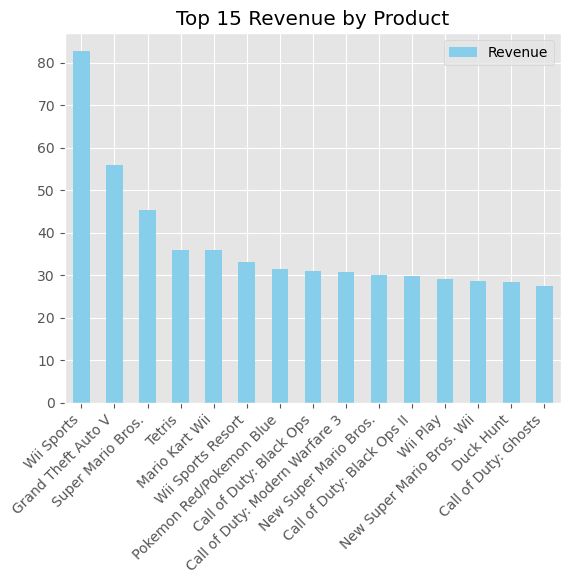

In [580]:
# create a figure
plt.figure()

# stacked vertical bar (column) chart
Top_15.plot.bar(color = 'skyblue')
plt.title('Top 15 Revenue by Product')
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel("")
plt.show()


In [581]:
pivot_sales_by_year = pd.pivot_table(df, values = ['Revenue'], index = ['Year'], columns = ['Territory'],
    aggfunc = ['sum'], fill_value = 0, margins = False)
pivot_sales_by_year = pivot_sales_by_year['sum']
pivot_sales_by_year = pivot_sales_by_year['Revenue']
pivot_sales_by_year

Territory,EU,Japan,North_America,Other
Year,,,,
1980,0.67,0.00,10.59,0.12
1981,1.96,0.00,33.40,0.32
1982,1.65,0.00,26.92,0.31
1983,0.80,8.10,7.76,0.14
1984,2.10,14.27,33.28,0.70
1985,4.74,14.56,33.73,0.92
1986,2.84,19.81,12.50,1.93
1987,1.41,11.63,8.46,0.20
1988,6.59,15.76,23.87,0.99


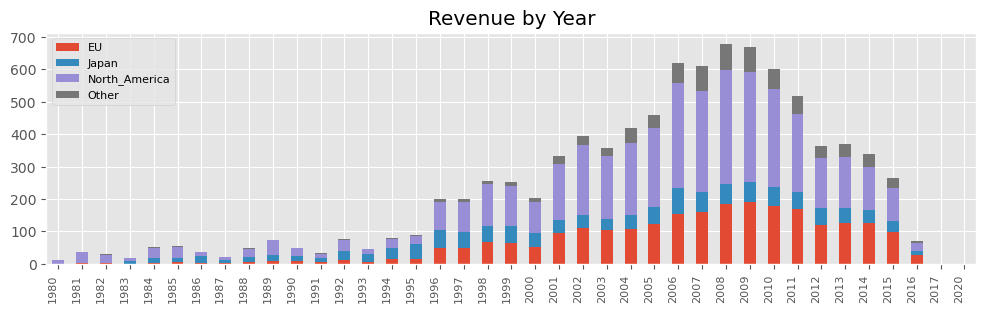

In [582]:
fig, ax = plt.subplots(figsize=(12, 3))

pivot_sales_by_year.plot.bar(
    stacked=True,
    title='Revenue by Year',
    ax=ax
)

ax.legend(['EU', 'Japan', 'North_America', 'Other'],
          loc='upper left', fontsize=8)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=8)
ax.set_xlabel("")

plt.show()

In [583]:
# create a pivot table
pivot_by_genre = pd.pivot_table(df, values = ['Revenue'], index = ['Genre'], columns = 'Territory',
    aggfunc = ['sum'], fill_value = 0, margins = False)

pivot_by_genre = pivot_by_genre['sum']
pivot_by_genre = pivot_by_genre['Revenue']

pivot_by_genre

Territory,EU,Japan,North_America,Other
Genre,,,,
Action,525.00,159.95,877.83,187.38
Adventure,64.13,52.07,105.80,16.81
Fighting,101.32,87.35,223.59,36.68
Misc,215.98,107.76,410.24,75.32
Platform,201.63,130.77,447.05,51.59
Puzzle,50.78,57.31,123.78,12.55
Racing,238.39,56.69,359.42,77.27
Role-Playing,188.06,352.31,327.28,59.61
Shooter,313.27,38.28,582.60,102.69


In [584]:
columnlist = list(pivot_by_genre.columns)


def add_pie_chart_by_territorylist(Territory):
    x = pivot_by_genre.index
    y = pivot_by_genre[Territory]

    # pie chart
    plt.figure(figsize=(7, 7))
    plt.pie(y, labels = x, autopct = '%.1f%%', pctdistance = 0.85)
    plt.title('Distribution of Genres by Territories')
    plt.show()


In [585]:
# interaction: Dropdown List widget (list value)
widgets.interact(add_pie_chart_by_territorylist, Territory = columnlist)


interactive(children=(Dropdown(description='Territory', options=('EU', 'Japan', 'North_America', 'Other'), val…

<function __main__.add_pie_chart_by_territorylist(Territory)>